# Transformers from Scratch -- the Number Flow

**Paper:** Vaswani et al., [*"Attention Is All You Need"*](https://arxiv.org/abs/1706.03762), NeurIPS 2017.

**Goal:** run a minimal encoder--decoder Transformer on the raw sequence `[1, 2, 3, 4, 5]`,
printing tensors and drawing a plot at every step so you can *see* what happens to the numbers.

> No words, no tokenization, no training -- just linear maps, softmax, and addition.

Every step quotes the matching equation from the paper (section numbers refer to the arXiv version).


## Setup

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings("ignore")

np.random.seed(42)
EPS = 1e-9

# -- shared plotting palette --------------------------------------
COLORS = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6"] # one per position
BG   = "#f8fafc"
plt.rcParams.update({
  "figure.facecolor" : BG,
  "axes.facecolor"  : "#ffffff",
  "axes.edgecolor"  : "#cbd5e1",
  "axes.labelcolor" : "#334155",
  "xtick.color"   : "#64748b",
  "ytick.color"   : "#64748b",
  "text.color"    : "#334155",
  "font.size"    : 10,
  "axes.titlesize"  : 12,
  "figure.dpi"    : 100,
})
print("Ready. Input sequence will be:", [1,2,3,4,5])


Ready. Input sequence will be: [1, 2, 3, 4, 5]


## Architecture at a Glance

<p align="center">
  <img src="images/transformer/fig1_transformer_architecture.png" width="380" alt="Transformer architecture, Figure 1 of the paper">
  <br><em>Figure 1 of the paper: "The Transformer -- model architecture."
  Encoder on the left, decoder on the right; each grey box is repeated N = 6 times.</em>
</p>

The paper's base model uses the following sizes (Section 3, Table 3). This notebook keeps the *structure*
and shrinks every dimension so all the numbers fit on screen:

| hyper-parameter | symbol | paper (base) | this notebook |
|---|---|---|---|
| layers per stack | $N$ | 6 | 1 |
| model width | $d_{model}$ | 512 | 4 |
| attention heads | $h$ | 8 | 1 |
| key / value width | $d_k = d_v = d_{model}/h$ | 64 | 4 |
| FFN inner width | $d_{ff}$ | 2048 | 8 |
| sequence length | $n$ | variable | 5 |

The diagram below re-draws Figure 1 and marks which blocks we implement (numbered by notebook step)
and which ones the paper has but we skip.

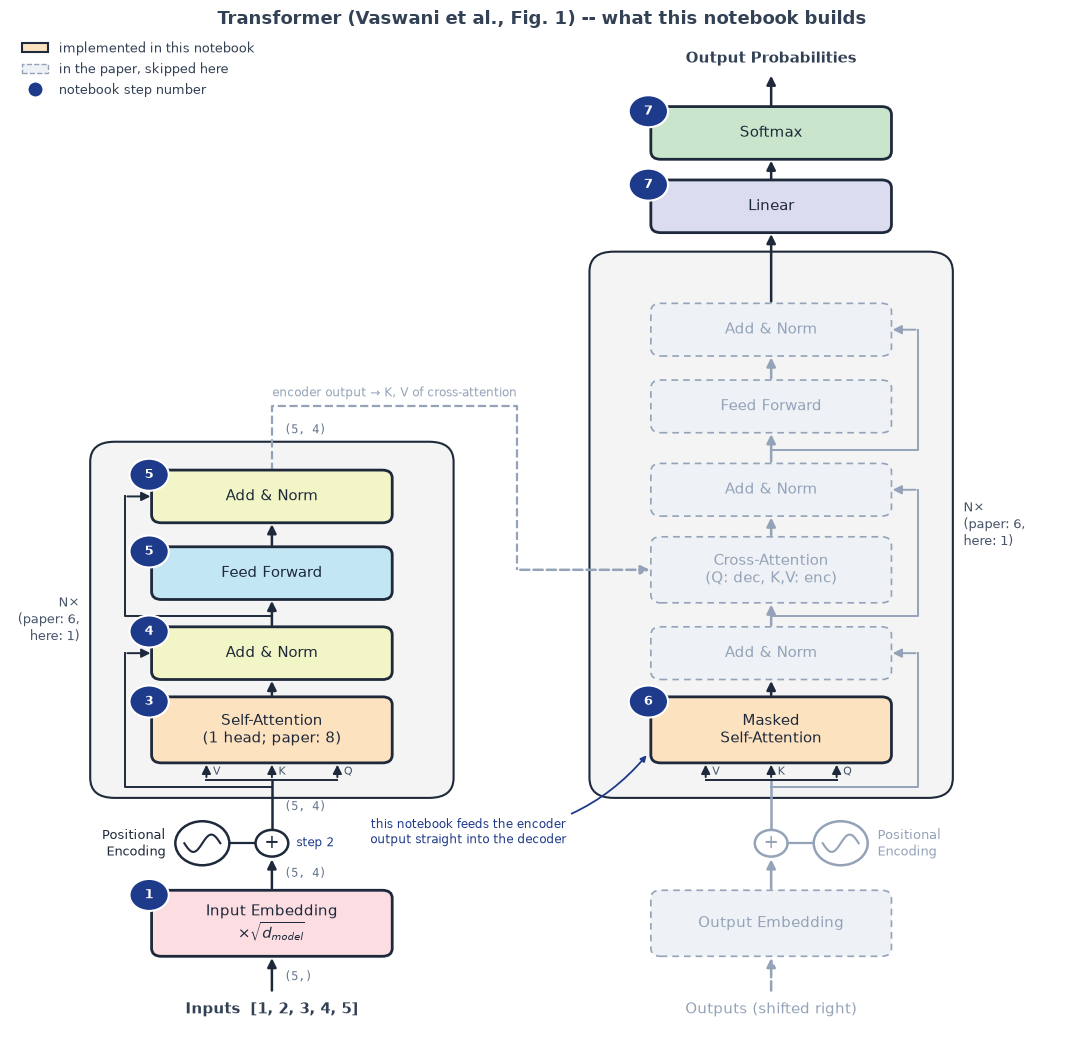

In [2]:
# -- Architecture map: paper's Figure 1, annotated with this notebook's steps --
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch

# paper colour scheme (Figure 1)
C_EMB, C_ATT, C_FFN = "#fbdde2", "#fde2bf", "#c3e6f5"
C_NORM, C_LIN, C_SM = "#f2f5c6", "#dcdcf0", "#c9e6cd"
C_OFF  = "#eef1f5"                      # blocks in the paper but skipped here
INK, MUTED = "#1e293b", "#94a3b8"

fig, ax = plt.subplots(figsize=(11, 10.5))
ax.set_xlim(0, 13); ax.set_ylim(-0.6, 14.4); ax.axis("off")
fig.patch.set_facecolor("white")

BW, BH = 2.9, 0.75                      # block width / height

def block(cx, cy, text, color, step=None, active=True, h=BH):
    face = color if active else C_OFF
    edge = INK if active else MUTED
    ax.add_patch(FancyBboxPatch((cx - BW/2, cy - h/2), BW, h,
                 boxstyle="round,pad=0.02,rounding_size=0.12",
                 fc=face, ec=edge, lw=2 if active else 1.2,
                 ls="-" if active else (0, (4, 3)), zorder=3))
    ax.text(cx, cy, text, ha="center", va="center", fontsize=10.5,
            color=INK if active else MUTED, zorder=4)
    if step is not None:                # numbered badge = notebook step
        ax.add_patch(Circle((cx - BW/2 - 0.05, cy + h/2 - 0.05), 0.24,
                     fc="#1e3a8a", ec="white", lw=1.5, zorder=5))
        ax.text(cx - BW/2 - 0.05, cy + h/2 - 0.05, str(step), ha="center",
                va="center", fontsize=9, color="white", weight="bold", zorder=6)

def arrow(p, q, color=INK, rad=0.0, lw=1.8, ls="-"):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=13,
                 color=color, lw=lw, ls=ls, zorder=2,
                 connectionstyle=f"arc3,rad={rad}"))

def residual(cx, y_from, y_to, color=INK, side=-1):
    """Skip connection drawn on the left (side=-1) or right (side=+1)."""
    x = cx + side * (BW/2 + 0.35)
    ax.plot([cx, x, x], [y_from, y_from, y_to], color=color, lw=1.4, zorder=1)
    arrow((x, y_to), (cx + side * BW/2, y_to), color=color, lw=1.4)

def qkv_fan(cx, y=3.15, top=3.9 - 0.48):
    """The same input is used three times: as V, K and Q (left to right, as in the paper)."""
    ax.plot([cx - 0.8, cx + 0.8], [y, y], color=INK, lw=1.4, zorder=2)
    for dx, name in zip((-0.8, 0, 0.8), "VKQ"):
        arrow((cx + dx, y), (cx + dx, top), lw=1.4)
        ax.text(cx + dx + 0.08, y + 0.08, name, fontsize=8, color="#475569", zorder=4)

def stack_frame(x0, y0, w, h, side):
    ax.add_patch(FancyBboxPatch((x0, y0), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.3",
                 fc="#f4f4f5", ec=INK, lw=1.5, zorder=0))
    tx = x0 - 0.15 if side < 0 else x0 + w + 0.15
    ax.text(tx, y0 + h/2, "N×\n(paper: 6,\nhere: 1)", ha="right" if side < 0 else "left",
            va="center", fontsize=9.5, color="#475569")

def pe_add(cx, cy, side, active=True):
    col = INK if active else MUTED
    ax.add_patch(Circle((cx, cy), 0.2, fc="white", ec=col, lw=1.8, zorder=3))
    ax.text(cx, cy, "+", ha="center", va="center", fontsize=13, color=col, zorder=4)
    wx = cx + side * 0.85
    ax.add_patch(Circle((wx, cy), 0.33, fc="white", ec=col, lw=1.8, zorder=3))
    t = np.linspace(-0.22, 0.22, 50)
    ax.plot(wx + t, cy + 0.13 * np.sin(t / 0.22 * np.pi), color=col, lw=1.5, zorder=4)
    ax.plot([cx + side*0.2, wx - side*0.33], [cy, cy], color=col, lw=1.6, zorder=2)
    ax.text(wx + side * 0.45, cy, "Positional\nEncoding", ha="left" if side > 0 else "right",
            va="center", fontsize=9, color=col)

# ---------------- encoder (left column) ----------------
E = 3.2
ax.text(E, -0.35, "Inputs  [1, 2, 3, 4, 5]", ha="center", fontsize=11, weight="bold")
block(E, 1.0, "Input Embedding\n" r"$\times\sqrt{d_{model}}$", C_EMB, step=1, h=0.95)
arrow((E, -0.05), (E, 1.0 - 0.48))
pe_add(E, 2.2, side=-1)
arrow((E, 1.48), (E, 2.0)); ax.text(E + 0.3, 2.2, "step 2", fontsize=8.5, color="#1e3a8a", va="center")

stack_frame(E - 2.2, 2.9, 4.4, 5.3, side=-1)
block(E, 3.9, "Self-Attention\n(1 head; paper: 8)", C_ATT, step=3, h=0.95)
block(E, 5.05, "Add & Norm", C_NORM, step=4)
block(E, 6.25, "Feed Forward", C_FFN, step=5)
block(E, 7.4, "Add & Norm", C_NORM, step=5)
ax.plot([E, E], [2.4, 3.15], color=INK, lw=1.8)
for (a, b) in [(4.38, 5.05 - BH/2), (5.43, 6.25 - BH/2), (6.63, 7.4 - BH/2)]:
    arrow((E, a), (E, b))
residual(E, 3.05, 5.05)                  # around attention
residual(E, 5.6, 7.4)                    # around FFN
# Q, K, V fan-in into the attention block
qkv_fan(E)

# shape annotations
for y, txt in [(0.2, "(5,)"), (1.75, "(5, 4)"), (2.75, "(5, 4)"), (8.4, "(5, 4)")]:
    ax.text(E + 0.15, y, txt, fontsize=8.5, family="monospace", color="#64748b", va="center")

# ---------------- decoder (right column) ----------------
D = 9.3
ax.text(D, -0.35, "Outputs (shifted right)", ha="center", fontsize=11, color=MUTED)
block(D, 1.0, "Output Embedding", C_EMB, active=False, h=0.95)
arrow((D, -0.05), (D, 1.0 - 0.48), color=MUTED, ls="--")
pe_add(D, 2.2, side=+1, active=False)
arrow((D, 1.48), (D, 2.0), color=MUTED)

stack_frame(D - 2.2, 2.9, 4.4, 8.15, side=+1)
block(D, 3.9, "Masked\nSelf-Attention", C_ATT, step=6, h=0.95)
block(D, 5.05, "Add & Norm", C_NORM, active=False)
block(D, 6.3, "Cross-Attention\n(Q: dec, K,V: enc)", C_ATT, active=False, h=0.95)
block(D, 7.5, "Add & Norm", C_NORM, active=False)
block(D, 8.75, "Feed Forward", C_FFN, active=False)
block(D, 9.9, "Add & Norm", C_NORM, active=False)
ax.plot([D, D], [2.4, 3.15], color=MUTED, lw=1.8)
qkv_fan(D)
arrow((D, 4.38), (D, 5.05 - BH/2))
for (a, b) in [(5.43, 6.3 - 0.48), (6.78, 7.5 - BH/2),
               (7.88, 8.75 - BH/2), (9.13, 9.9 - BH/2)]:
    arrow((D, a), (D, b), color=MUTED)
residual(D, 3.05, 5.05, color=MUTED, side=+1)
residual(D, 5.6, 7.5, color=MUTED, side=+1)
residual(D, 8.1, 9.9, color=MUTED, side=+1)

block(D, 11.75, "Linear", C_LIN, step=7)
block(D, 12.85, "Softmax", C_SM, step=7)
arrow((D, 10.28), (D, 11.75 - BH/2))
arrow((D, 11.75 + BH/2), (D, 12.85 - BH/2))
arrow((D, 12.85 + BH/2), (D, 13.75))
ax.text(D, 13.85, "Output Probabilities", ha="center", va="bottom", fontsize=11, weight="bold")

# encoder memory -> cross-attention K, V (paper wiring, skipped here)
ax.plot([E, E, 6.2, 6.2], [7.78, 8.75, 8.75, 6.3], color=MUTED, lw=1.6, ls="--", zorder=1)
arrow((6.2, 6.3), (D - BW/2, 6.3), color=MUTED, ls="--")
ax.text(4.7, 8.9, "encoder output → K, V of cross-attention", fontsize=8.5, color=MUTED, ha="center")

# what this notebook actually feeds the decoder
ax.annotate("this notebook feeds the encoder\noutput straight into the decoder",
            xy=(D - BW/2 - 0.05, 3.55), xytext=(5.6, 2.2), fontsize=8.5,
            color="#1e3a8a", ha="center",
            arrowprops=dict(arrowstyle="-|>", color="#1e3a8a", lw=1.3,
                            connectionstyle="arc3,rad=0.25"))

# legend
handles = [mpatches.Patch(fc=C_ATT, ec=INK, lw=1.5, label="implemented in this notebook"),
           mpatches.Patch(fc=C_OFF, ec=MUTED, ls="--", label="in the paper, skipped here"),
           Line2D([], [], marker="o", ls="", ms=11, mfc="#1e3a8a", mec="white",
                  label="notebook step number")]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.0, 1.0), fontsize=9.5, frameon=False)
ax.set_title("Transformer (Vaswani et al., Fig. 1) -- what this notebook builds",
             fontsize=13, weight="bold", pad=4)
plt.tight_layout()
plt.show()

## Step 0 -- Raw Input

A flat list of five numbers. No vocabulary, no tokens -- just `float`s.
In a real model each number would stand in for one *token* (word, sub-word, etc.).

In [3]:
seq = [1.0, 2.0, 3.0, 4.0, 5.0]
x  = np.array(seq)     # shape (5,)
print("input:", seq)
print("shape:", x.shape)


input: [1.0, 2.0, 3.0, 4.0, 5.0]
shape: (5,)


## Step 1 -- Embedding $x \rightarrow$ vector

Section 3.4 *(Embeddings and Softmax)*: the model uses **learned embeddings** to turn each token into a
vector of size $d_{model}$, and *"in the embedding layers, we multiply those weights by $\sqrt{d_{model}}$"*:

$$
\mathrm{Emb}(t) = \sqrt{d_{model}} \; E[t], \qquad E \in \mathbb{R}^{|\mathcal{V}| \times d_{model}}
$$

A real model does a table **lookup** $E[t]$. Our inputs are plain numbers, so we stand in for the lookup with
a single random row $w_{emb} \in \mathbb{R}^{1 \times d_{model}}$ scaled by the input value:

$$
X_i = \sqrt{d_{model}} \; x_i \, w_{emb}, \qquad X \in \mathbb{R}^{5 \times 4}
$$

Each position becomes a **4-dimensional feature vector** (standing in for the 512-dim vectors in the paper).

embedding matrix X, shape (5, 4)
[[ 0.497 -0.138  0.648  1.523]
 [ 0.993 -0.277  1.295  3.046]
 [ 1.49  -0.415  1.943  4.569]
 [ 1.987 -0.553  2.591  6.092]
 [ 2.484 -0.691  3.238  7.615]]


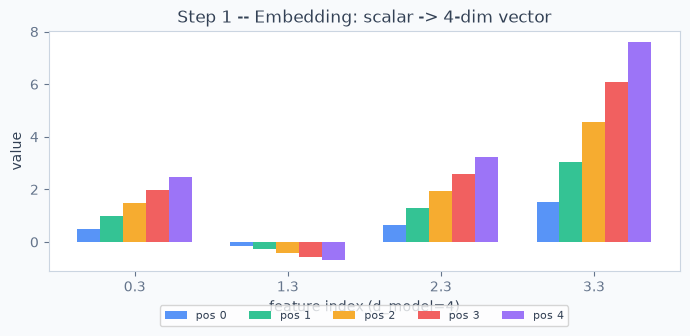

In [4]:
d_model = 4

# W_embed: shape (1, 4) -- a single random "vocabulary row"
# In a real model this would be a full matrix: (vocab_size, d_model)
W_embed = np.random.randn(1, d_model) * 0.5
X = x[:, None] * W_embed * np.sqrt(d_model)  # (5, 4)

print("embedding matrix X, shape", X.shape)
print(X.round(3))

# -- plot: one bar per feature, colour per position --------------
fig, ax = plt.subplots(figsize=(7, 3.5))
positions = range(len(seq))
width   = 0.15
cols   = COLORS
for j in range(len(seq)):
  ax.bar(np.arange(d_model) + j * width, X[j], width, label=f"pos {j}", color=cols[j], alpha=0.85)

ax.set_xlabel("feature index (d_model=4)")
ax.set_ylabel("value")
ax.set_title("Step 1 -- Embedding: scalar -> 4-dim vector")
ax.set_xticks(np.arange(d_model) + (len(seq)-1)*width/2)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=8)
plt.tight_layout()
plt.show()


## Step 2 -- Positional Encoding $(X + PE)$

The Transformer has no recurrence and no convolution, so it has no built-in notion of order.
Section 3.5 injects position with **fixed sinusoids** added to the embeddings:

$$
PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{\,2i/d_{model}}}\right), \qquad
PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{\,2i/d_{model}}}\right)
$$

where $pos$ is the position and $i$ is the dimension index. *"The wavelengths form a geometric progression
from $2\pi$ to $10000 \cdot 2\pi$."* The paper chose sinusoids because, for any fixed offset $k$,
$PE_{pos+k}$ is a **linear function** of $PE_{pos}$, which should make relative positions easy to attend to.

The encoding is **added**, not concatenated, so the width stays $d_{model}$:

$$
X \leftarrow X + PE
$$

In the code, `div` $= 10000^{-2i/d_{model}}$ is computed as $\exp\!\big(-2i \cdot \ln(10000)/d_{model}\big)$
for numerical stability.

PE matrix: [[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]
 [ 0.141 -0.99   0.03   1.   ]
 [-0.757 -0.654  0.04   0.999]]

X + PE:
[[ 0.497  0.862  0.648  2.523]
 [ 1.835  0.264  1.305  4.046]
 [ 2.399 -0.831  1.963  5.569]
 [ 2.128 -1.543  2.621  7.092]
 [ 1.727 -1.345  3.278  8.614]]


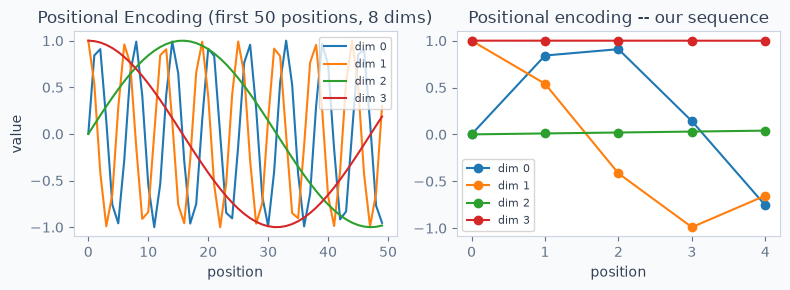

In [5]:
def positional_encoding(seq_len, d):
  pe = np.zeros((seq_len, d))
  pos = np.arange(seq_len)[:, None]
  div = np.exp(np.arange(0, d, 2) * (-np.log(10000.0) / d))
  pe[:, 0::2] = np.sin(pos * div)
  pe[:, 1::2] = np.cos(pos * div)
  return pe

PE = positional_encoding(len(seq), d_model)
print("PE matrix:", PE.round(3))

# add to embeddings
X = X + PE
print("\nX + PE:")
print(X.round(3))

# -- plot: PE waveform --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
pe_big = positional_encoding(50, 8)

positions_range = np.arange(50)
for j in range(4):
  axes[0].plot(positions_range, pe_big[:, j], label=f"dim {j}", lw=1.5)
axes[0].set_title("Positional Encoding (first 50 positions, 8 dims)")
axes[0].set_xlabel("position")
axes[0].set_ylabel("value")
axes[0].legend(fontsize=8)
axes[0].set_ylim(-1.1, 1.1)

for j in range(d_model):
  axes[1].plot(range(len(seq)), PE[:, j], "o-", label=f"dim {j}")
axes[1].set_title("PE for our 5 positions (d=4)")
axes[1].set_xlabel("position")
axes[1].set_title("Positional encoding -- our sequence")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Helpers

Three functions that every later step re-uses:

* **Softmax** (numerically stable: subtract the row max before exponentiating):
  $\;\mathrm{softmax}(z)_j = \dfrac{e^{z_j - \max z}}{\sum_k e^{z_k - \max z}}$
* **Layer normalisation** (Ba et al., 2016), without the learned gain/bias for simplicity:
  $\;\mathrm{LayerNorm}(x) = \dfrac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$, with $\mu, \sigma^2$ taken over the $d_{model}$ features of each position
* **Scaled dot-product attention**, Equation (1) of the paper (explained in Step 3)

In [6]:
def softmax(z, axis=-1):
  e = z - z.max(axis=axis, keepdims=True)
  e = np.exp(e)
  return e / (e.sum(axis=axis, keepdims=True) + EPS)

def layer_norm(x):
  mean = x.mean(axis=-1, keepdims=True)
  var = x.var(axis=-1, keepdims=True)
  return (x - mean) / np.sqrt(var + EPS)

def scaled_dot_attention(Q, K, V, mask=None):
  """
  scores = Q @ K.T / sqrt(d_k)     # (L, d) x (d, L) -> (L, L)
  weights = softmax(scores)       # rows sum to 1
  output = weights @ V         # (L, L) x (L, d) -> (L, d)
  """
  d_k  = Q.shape[-1]
  scores = Q @ K.T / np.sqrt(d_k)
  if mask is not None:
    scores = np.where(mask == 0, -1e9, scores)
  weights = softmax(scores, axis=-1)
  return weights @ V, weights

print("helpers defined")


helpers defined


## Step 3 -- Self-Attention *(the core of the whole paper)*

> *"An attention function can be described as mapping a query and a set of key-value pairs to an output,
> where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
> of the values, where the weight assigned to each value is computed by a compatibility function of the
> query with the corresponding key."* -- Section 3.2

Each position plays three roles at once, obtained by three learned projections of the same input $X$:

| role  | formula     | intuition                          |
|-------|-------------|------------------------------------|
| Query | $Q = XW^Q$  | "what am I looking for?"           |
| Key   | $K = XW^K$  | "what do I contain / offer?"       |
| Value | $V = XW^V$  | "what do I actually contribute?"   |

### Scaled Dot-Product Attention -- Equation (1)

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

<table><tr>
<td align="center" width="35%"><img src="images/transformer/fig2a_scaled_dot_product_attention.png" width="170"></td>
<td align="center" width="65%"><img src="images/transformer/fig2b_multi_head_attention.png" width="300"></td>
</tr><tr><td colspan="2" align="center"><em>Figure 2 of the paper: (left) Scaled Dot-Product Attention.
(right) Multi-Head Attention consists of several attention layers running in parallel.</em></td></tr></table>

Read the left diagram bottom-up -- it is exactly `scaled_dot_attention()` above:
`MatMul` $QK^\top$ $\rightarrow$ `Scale` by $1/\sqrt{d_k}$ $\rightarrow$ optional `Mask` (Step 6) $\rightarrow$
`SoftMax` $\rightarrow$ `MatMul` with $V$.

**Why divide by $\sqrt{d_k}$?** Footnote 4 of the paper: if the components of $q$ and $k$ are independent
with mean 0 and variance 1, then

$$
q \cdot k = \sum_{i=1}^{d_k} q_i k_i \quad\text{has mean } 0 \text{ and variance } d_k .
$$

For large $d_k$ the scores get large, the softmax saturates and its gradients vanish. Dividing by $\sqrt{d_k}$
brings the variance back to 1.

### Multi-Head Attention (Section 3.2.2)

$$
\begin{aligned}
\mathrm{MultiHead}(Q, K, V) &= \mathrm{Concat}(\mathrm{head}_1, \dots, \mathrm{head}_h)\,W^O \\
\text{where}\;\; \mathrm{head}_i &= \mathrm{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)
\end{aligned}
$$

with $W_i^Q, W_i^K \in \mathbb{R}^{d_{model} \times d_k}$, $W_i^V \in \mathbb{R}^{d_{model} \times d_v}$,
$W^O \in \mathbb{R}^{h d_v \times d_{model}}$. The paper uses $h = 8$ heads with $d_k = d_v = 512/8 = 64$, so the total
cost is about the same as one full-width head. *"Multi-head attention allows the model to jointly attend to
information from different representation subspaces at different positions."*

Here we use **one head** ($h = 1$, $d_k = d_{model} = 4$, no $W^O$), which is the left diagram on its own.

Q shape: (5, 4)  K shape: (5, 4)  V shape: (5, 4)

Raw scores (Q KT / sqrt4):
[[0.937 1.03  0.788 0.596 0.791]
 [1.807 2.349 2.54  2.799 3.48 ]
 [2.714 3.748 4.264 4.79  5.843]
 [3.571 4.97  5.496 5.939 7.164]
 [4.339 5.92  6.225 6.392 7.685]]

Attention weights (softmax of scores, each row sums to 1):
[[0.2205 0.242  0.19   0.1568 0.1907]
 [0.078  0.134  0.1623 0.2102 0.4155]
 [0.0254 0.0715 0.1197 0.2025 0.5809]
 [0.017  0.0687 0.1163 0.1812 0.6168]
 [0.0206 0.0999 0.1356 0.1601 0.5838]]


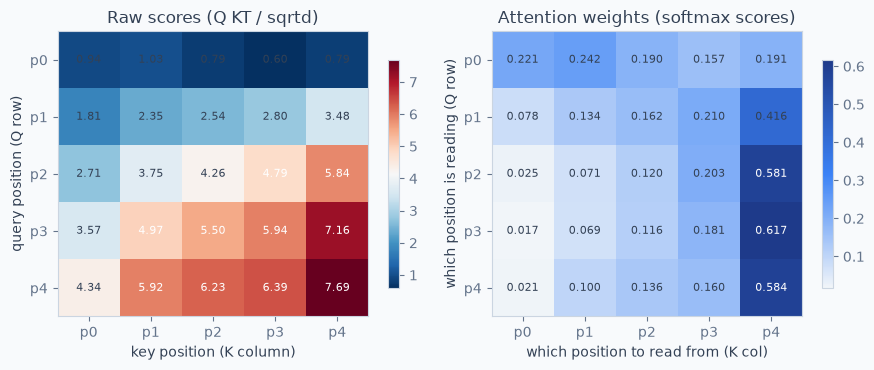

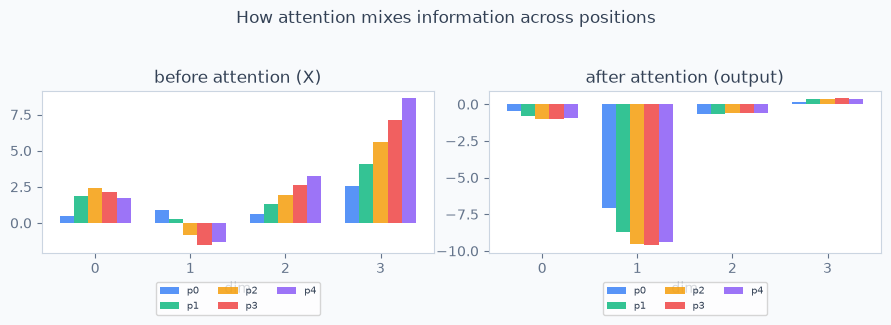

In [7]:
W_Q = np.random.randn(d_model, d_model) * 0.5
W_K = np.random.randn(d_model, d_model) * 0.5
W_V = np.random.randn(d_model, d_model) * 0.5

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

attn_out, attn_w = scaled_dot_attention(Q, K, V)

print("Q shape:", Q.shape, " K shape:", K.shape, " V shape:", V.shape)
print("\nRaw scores (Q KT / sqrt4):")
print((Q @ K.T / np.sqrt(d_model)).round(3))
print("\nAttention weights (softmax of scores, each row sums to 1):")
print(attn_w.round(4))

# -- HIGHLIGHT: attention weight heatmap -------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

# Left: raw scores
scores = Q @ K.T / np.sqrt(d_model)
im0 = axes[0].imshow(scores, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Raw scores (Q KT / sqrtd)")
axes[0].set_xlabel("key position (K column)")
axes[0].set_ylabel("query position (Q row)")
axes[0].set_xticks(range(len(seq)))
axes[0].set_yticks(range(len(seq)))
for i in range(len(seq)):
  for j in range(len(seq)):
    axes[0].text(j, i, f"{scores[i,j]:.2f}",
           ha="center", va="center", fontsize=8,
           color="white" if abs(scores[i,j]) > scores.max()*0.6 else "#334155")
axes[0].set_xticklabels([f"p{j}" for j in range(len(seq))])
axes[0].set_yticklabels([f"p{i}" for i in range(len(seq))])
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Right: softmax weights (the actual "where to look" matrix)
cmap_w = LinearSegmentedColormap.from_list("w", ["#f1f5f9", "#3b82f6", "#1e3a8a"])
im1 = axes[1].imshow(attn_w, cmap=cmap_w, aspect="auto")
axes[1].set_title("Attention weights (softmax scores)")
axes[1].set_xlabel("which position to read from (K col)")
axes[1].set_ylabel("which position is reading (Q row)")
axes[1].set_xticks(range(len(seq)))
axes[1].set_yticks(range(len(seq)))
for i in range(len(seq)):
  for j in range(len(seq)):
    col = "white" if attn_w[i,j] > 0.45 else "#334155"
    axes[1].text(j, i, f"{attn_w[i,j]:.3f}", ha="center", va="center",
           fontsize=8, color=col)
axes[1].set_xticklabels([f"p{j}" for j in range(len(seq))])
axes[1].set_yticklabels([f"p{i}" for i in range(len(seq))])
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# -- plot: before -> after attention for each position ------------
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

for ax, data, label in[(axes[0], X, "before attention (X)"),
            (axes[1], attn_out, "after attention (output)")]:
  for j in range(len(seq)):
    ax.bar(np.arange(d_model)+j*0.15, data[j], 0.15,
        label=f"p{j}", color=COLORS[j], alpha=0.85)
  ax.set_title(label)
  ax.set_xlabel("dim")
  ax.set_xticks(np.arange(d_model)+ (len(seq)-1)*0.075)
  ax.set_xticklabels(range(d_model))
  ax.legend(fontsize=7, ncol=3, loc="upper center",
       bbox_to_anchor=(0.5, -0.15))

fig.suptitle("How attention mixes information across positions", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()


### What trained attention heads look like

Our weights are random, so the heatmap above has no meaning yet. The paper's appendix shows what
heads in a **trained** model (encoder self-attention, layer 5 of 6) learn to do:

<p align="center">
  <img src="images/transformer/fig3_long_distance_dependency.png" width="620"><br>
  <em>Figure 3 of the paper: attention following a long-distance dependency. Many heads attend from
  <code>making</code> to the distant <code>more difficult</code>, completing the phrase "making ... more difficult".
  Different colours are different heads.</em>
</p>

<p align="center">
  <img src="images/transformer/fig4_anaphora_resolution.png" width="520"><br>
  <em>Figure 4 (bottom) of the paper: two heads apparently involved in anaphora resolution --
  from the word <code>its</code> they attend sharply to <code>Law</code> and <code>application</code>.</em>
</p>

Each line in these figures is one entry of the weights matrix $\mathrm{softmax}(QK^\top/\sqrt{d_k})$
we just computed: row = the word doing the attending (query), column = the word being read (key).

## Step 4 -- Residual Connection + Layer Normalisation (*Add & Norm*)

Section 3.1: *"We employ a residual connection around each of the two sub-layers, followed by layer
normalization. That is, the output of each sub-layer is"*

$$
\mathrm{LayerNorm}\big(x + \mathrm{Sublayer}(x)\big)
$$

*"where $\mathrm{Sublayer}(x)$ is the function implemented by the sub-layer itself."* This is the
**Add & Norm** box that follows every sub-layer in Figure 1.

* The **residual** ($+\,x$) lets information and gradients skip the sub-layer, so deep stacks stay trainable.
  It is also why every sub-layer must output exactly $d_{model}$ features.
* **Layer Norm** rescales each position to mean $\approx 0$, std $\approx 1$, so the next layer sees well-scaled inputs:

$$
\mathrm{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta,
\qquad \mu = \tfrac{1}{d}\textstyle\sum_j x_j,\;\; \sigma^2 = \tfrac{1}{d}\sum_j (x_j - \mu)^2
$$

(our `layer_norm` fixes $\gamma = 1$, $\beta = 0$).

This is the *post-LN* placement from the paper. Most modern models (GPT-2 onwards) use *pre-LN*:
$x + \mathrm{Sublayer}(\mathrm{LayerNorm}(x))$, which trains more stably in deep stacks.

after residual + layer-norm:
[[ 0.2811 -1.6325  0.2616  1.0898]
 [ 0.3406 -1.6496  0.2633  1.0456]
 [ 0.2986 -1.6466  0.2927  1.0554]
 [ 0.1814 -1.6172  0.3171  1.1186]
 [ 0.0478 -1.5659  0.3155  1.2026]]


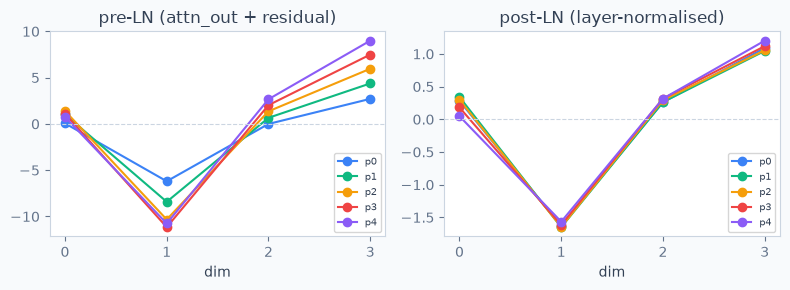

In [8]:
pre_ln = attn_out + X          # Add  (residual)
X = layer_norm(pre_ln)         # Norm
print("after residual + layer-norm:")
print(X.round(4))

# -- plot: show the normalising effect ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, data, title in[(axes[0], pre_ln, "pre-LN (attn_out + residual)"),
            (axes[1], X,  "post-LN (layer-normalised)")]:
  for j in range(len(seq)):
    ax.plot(np.arange(d_model), data[j], "o-", label=f"p{j}", color=COLORS[j])
  ax.set_title(title)
  ax.set_xlabel("dim")
  ax.set_xticks(range(d_model))
  ax.set_xticklabels(range(d_model))
  ax.axhline(0, color="#cbd5e1", lw=0.8, ls="--")
  ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 5 -- Position-wise Feed-Forward Network

Section 3.3: each layer contains *"a fully connected feed-forward network, which is applied to each
position separately and identically. This consists of two linear transformations with a ReLU activation
in between"* -- Equation (2):

$$
\mathrm{FFN}(x) = \max(0,\; xW_1 + b_1)\,W_2 + b_2
$$

with $W_1 \in \mathbb{R}^{d_{model} \times d_{ff}}$ and $W_2 \in \mathbb{R}^{d_{ff} \times d_{model}}$.
The paper uses $d_{model} = 512$ and $d_{ff} = 2048$ (a 4x expansion); we use $4 \rightarrow 8 \rightarrow 4$.

*"Another way of describing this is as two convolutions with kernel size 1."* Because no information
moves between positions here, all 5 rows are processed in a single matrix multiply.
Attention mixes **across** positions; the FFN transforms **within** each position.

The FFN is again wrapped in Add & Norm: $X \leftarrow \mathrm{LayerNorm}\big(X + \mathrm{FFN}(X)\big)$.

intermediate h (5x8):
[[0.391 0.    1.145 0.225 0.    0.    0.568 0.   ]
 [0.373 0.016 1.184 0.309 0.    0.    0.544 0.   ]
 [0.392 0.    1.166 0.3   0.    0.    0.505 0.   ]
 [0.432 0.    1.097 0.184 0.    0.    0.499 0.   ]
 [0.468 0.    1.003 0.006 0.    0.    0.54  0.   ]]

final after FFN + residual + LN (5x4):
[[ 0.4355 -1.6671  0.2464  0.9852]
 [ 0.5149 -1.6864  0.2657  0.9058]
 [ 0.4409 -1.6921  0.3431  0.9081]
 [ 0.2547 -1.6576  0.3827  1.0202]
 [ 0.0698 -1.5835  0.3434  1.1703]]


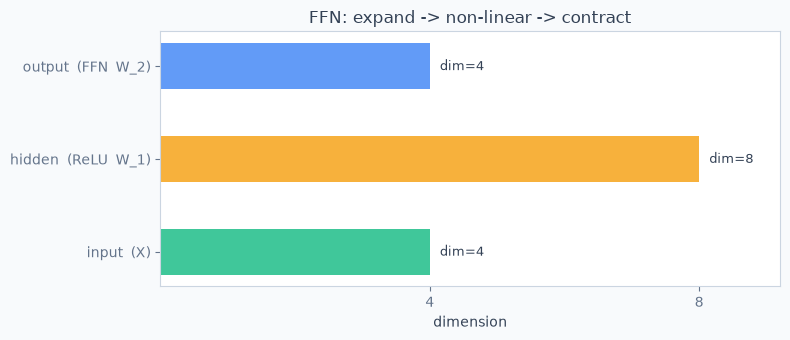

In [9]:
d_ff = 8   # paper: d_ff = 4 x d_model -> 4x4 = 16 here we use 8 for clarity
W1 = np.random.randn(d_model, d_ff) * 0.5  # (4, 8)
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff, d_model) * 0.5  # (8, 4)
b2 = np.zeros(d_model)

h   = np.maximum(0, X @ W1 + b1)     # (5, 8) <- expanded
ffn  = h @ W2 + b2             # (5, 4) <- projected back
X   = layer_norm(ffn + X)         # residual + LN

print("intermediate h (5x8):")
print(h.round(3))
print("\nfinal after FFN + residual + LN (5x4):")
print(X.round(4))

# -- plot: expansion/contraction funnel --------------------------
fig, ax = plt.subplots(figsize=(8, 3.5))

widths = [d_model, d_ff, d_model]
labels = [f"d_model\n({d_model})", f"d_ff\n({d_ff})", f"d_model\n({d_model})"]
colours= ["#3b82f6", "#f59e0b", "#10b981"]
bars  = ax.barh([2,1,0], widths, height=0.5, color=colours, alpha=0.8)
ax.set_yticks([2,1,0])
ax.set_yticklabels(["output  (FFN  W_2)", "hidden  (ReLU  W_1)", "input  (X)"])
for bar, w in zip(bars, widths):
  ax.text(w + 0.15, bar.get_y() + bar.get_height()/2, f"dim={w}",
      va="center", fontsize=9)
ax.set_xlim(0, d_ff * 1.15)
ax.set_xlabel("dimension")
ax.set_title("FFN: expand -> non-linear -> contract")
ax.set_xticks([d_model, d_ff])
plt.tight_layout()
plt.show()


## Step 6 -- Causal (Masked) Self-Attention *(decoder)*

Section 3.2.3: *"We need to prevent leftward information flow in the decoder to preserve the
auto-regressive property. We implement this inside of scaled dot-product attention by masking out
(setting to $-\infty$) all values in the input of the softmax which correspond to illegal connections."*
This is the optional **Mask** box in Figure 2 (left).

$$
\mathrm{MaskedAttention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V,
\qquad
M_{ij} = \begin{cases} 0 & j \le i \\ -\infty & j > i \end{cases}
$$

Since $e^{-\infty} = 0$, position $i$ gives exactly zero weight to every later position $j > i$.
Together with the output embeddings being *"offset by one position"* (the *shifted right* input in Figure 1),
this ensures *"the predictions for position $i$ can depend only on the known outputs at positions less than $i$."*

The allowed pattern is lower-triangular:

$$
\mathbb{1}[j \le i] =
\begin{bmatrix}
1&0&0&0&0\\ 1&1&0&0&0\\ 1&1&1&0&0\\ 1&1&1&1&0\\ 1&1&1&1&1
\end{bmatrix}
$$

Each row still sums to 1 after masking -- the position simply redistributes its "attention budget"
over the allowed predecessors. (In code we use $-10^9$ instead of $-\infty$ to avoid `nan`.)

> **Simplification:** a real decoder reads the *output embeddings* (shifted right). To keep the demo short,
> we feed the encoder output $X$ straight into the decoder's masked self-attention (see the diagram above).

causal mask (1=allowed, 0=blocked):
[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]
 [1 1 1 1 1]]

causal attention weights:
[[1.     0.     0.     0.     0.    ]
 [0.4733 0.5267 0.     0.     0.    ]
 [0.311  0.3452 0.3438 0.     0.    ]
 [0.2405 0.2653 0.2664 0.2278 0.    ]
 [0.2035 0.223  0.2252 0.1953 0.1531]]


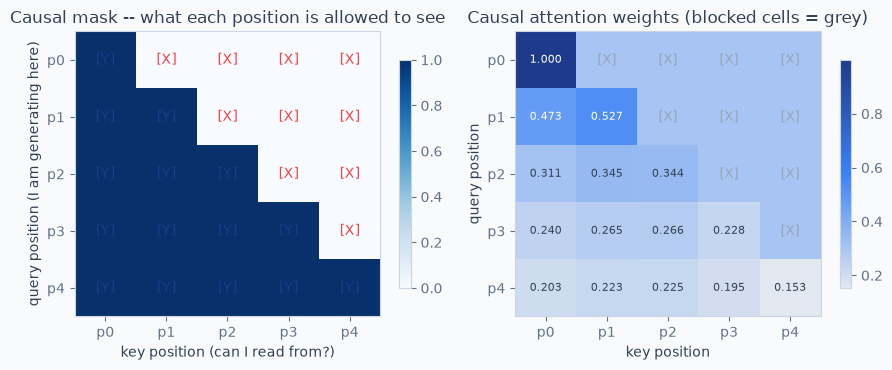


-> p0: sees only itself     -> weights = [1.0, 0, 0, 0, 0]
-> p4: sees all 5 positions  -> weights distribute over p0...p4


In [10]:
L   = len(seq)
causal = np.tril(np.ones((L, L)))

Q_dec = X @ np.random.randn(d_model, d_model) * 0.5
K_dec = X @ np.random.randn(d_model, d_model) * 0.5
V_dec = X @ np.random.randn(d_model, d_model) * 0.5

dec_out, dec_attn = scaled_dot_attention(Q_dec, K_dec, V_dec, mask=causal)

print("causal mask (1=allowed, 0=blocked):")
print(causal.astype(int))
print("\ncausal attention weights:")
print(dec_attn.round(4))

# -- plot: masked heatmap ----------------------------------------
# Build a display matrix: masked cells shown as empty grey, attended cells coloured
display = np.full((L, L), 0.3)
display[causal == 1] = dec_attn[causal == 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

# Left: show what's allowed
im0 = axes[0].imshow(causal, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[0].set_title("Causal mask -- what each position is allowed to see")
axes[0].set_xlabel("key position (can I read from?)")
axes[0].set_ylabel("query position (I am generating here)")
axes[0].set_xticks(range(L)); axes[0].set_yticks(range(L))
axes[0].set_xticklabels([f"p{j}" for j in range(L)])
axes[0].set_yticklabels([f"p{i}" for i in range(L)])
for i in range(L):
  for j in range(L):
    axes[0].text(j, i, "[Y]" if causal[i,j] else "[X]", ha="center", va="center",
           fontsize=10, color="#1e3a8a" if causal[i,j]==1 else "#ef4444")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Right: actual weights, blocked cells greyed
cmap_d = LinearSegmentedColormap.from_list("d", ["#e2e8f0", "#3b82f6", "#1e3a8a"])
im1 = axes[1].imshow(display, cmap=cmap_d, aspect="auto")
axes[1].set_title("Causal attention weights (blocked cells = grey)")
axes[1].set_xlabel("key position")
axes[1].set_ylabel("query position")
axes[1].set_xticks(range(L)); axes[1].set_yticks(range(L))
axes[1].set_xticklabels([f"p{j}" for j in range(L)])
axes[1].set_yticklabels([f"p{i}" for i in range(L)])
for i in range(L):
  for j in range(L):
    if causal[i,j]:
      axes[1].text(j, i, f"{dec_attn[i,j]:.3f}",
             ha="center", va="center", fontsize=8,
             color="white" if dec_attn[i,j]>0.4 else "#334155")
    else:
      axes[1].text(j, i, "[X]", ha="center", va="center", fontsize=9, color="#94a3b8")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print()
print("-> p0: sees only itself     -> weights = [1.0, 0, 0, 0, 0]")
print("-> p4: sees all 5 positions  -> weights distribute over p0...p4")

## Step 6b (skipped here) -- Encoder-Decoder (Cross-) Attention

Section 3.2.3: *"In 'encoder-decoder attention' layers, the queries come from the previous decoder layer,
and the memory keys and values come from the output of the encoder. This allows every position in the
decoder to attend over all positions in the input sequence."*

$$
\mathrm{CrossAttention}(Y, Z) = \mathrm{softmax}\!\left(\frac{(YW^Q)(ZW^K)^\top}{\sqrt{d_k}}\right) ZW^V
$$

where $Y$ is the decoder state (target side, length $m$) and $Z$ is the encoder output (source side, length $n$).
The weight matrix is $m \times n$ -- it need not be square -- and no causal mask is needed, because the
whole source sentence is known in advance.

This is the middle orange block of the decoder in Figure 1 and how "translate this French sentence" works.
We skip it because our encoder and decoder operate on the same 5 numbers, but it is a one-liner with our
helper: `scaled_dot_attention(Y @ W_Q, Z @ W_K, Z @ W_V)`.

## Step 7 -- Output Projection $\rightarrow$ Logits $\rightarrow$ Probabilities

Section 3.4: *"We also use the usual learned linear transformation and softmax function to convert the
decoder output to predicted next-token probabilities."* These are the **Linear** and **Softmax** boxes at the
top of Figure 1:

$$
\text{logits} = Y W_{out} \in \mathbb{R}^{n \times |\mathcal{V}|}, \qquad
P(y_t \mid y_{<t}, x) = \mathrm{softmax}(\text{logits}_t), \qquad
\hat y_t = \arg\max_v P(y_t = v \mid \cdot)
$$

The paper also *shares* weights: the two embedding matrices and $W_{out}$ are the same matrix
(up to the $\sqrt{d_{model}}$ scale).

In this toy demo $|\mathcal{V}| = 1$ (we map each position back to a single scalar), so for visualisation
we apply the softmax across the 5 positions instead of across a vocabulary. The shapes up to the
logits are exactly what the real model computes.

logits per position:
  [0.6985, 0.7368, 0.7548, 0.7408, 0.7078]

fake softmax probabilities (sum=1):
  [0.1942, 0.2018, 0.2054, 0.2026, 0.196]


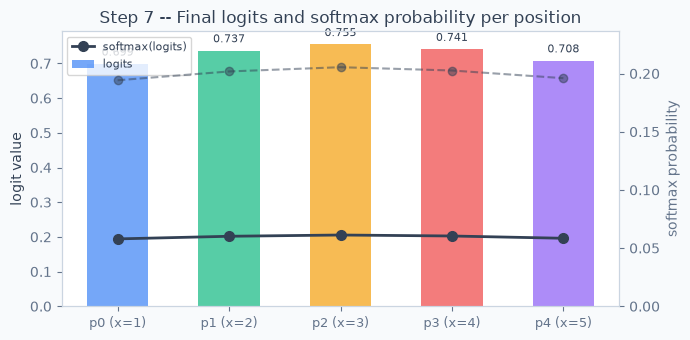

In [11]:
W_out = np.random.randn(d_model, 1) * 0.5
logits = (dec_out @ W_out).squeeze()  # (5,)

# fake "probability" distribution over positions for visualisation
probs = softmax(logits, axis=0)

print("logits per position:")
print(" ", np.round(logits, 4).tolist())
print("\nfake softmax probabilities (sum=1):")
print(" ", np.round(probs, 4).tolist())

# -- plot: logits + probs as a combined bar+line chart -----------
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(range(L), logits, color=COLORS, alpha=0.7, width=0.55, label="logits")
ax.plot(range(L), probs, "o-", color="#334155", lw=2, markersize=7, label="softmax(logits)")

# twin axis for probs
ax2 = ax.twinx()
ax2.plot(range(L), probs, "o--", color="#334155", lw=1.5, markersize=6, alpha=0.5)
ax2.set_ylabel("softmax probability", color="#64748b")
ax2.set_ylim(0, max(probs) * 1.15)

ax.set_xticks(range(L))
ax.set_xticklabels([f"p{i} (x={seq[i]:.0f})" for i in range(L)], fontsize=9)
ax.set_ylabel("logit value")
ax.set_title("Step 7 -- Final logits and softmax probability per position")
ax.legend(fontsize=8, loc="upper left")

# annotate values
for i, (l, p) in enumerate(zip(logits, probs)):
  ax.annotate(f"{l:.3f}", (i, l), textcoords="offset points",
        xytext=(0, 6), ha="center", fontsize=8)

plt.tight_layout()
plt.show()


## Recap -- what we just did, one line per step

| # | Operation | paper | shape flow |
|---|---|---|---|
| 0 | Input scalars | -- | `(5,)` |
| 1 | Embedding: $\sqrt{d_{model}}\; x\, w_{emb}$ | §3.4 | `(5,) -> (5,4)` |
| 2 | $X + PE$ (sinusoidal) | §3.5 | `(5,4)` |
| 3 | Self-attention: $\mathrm{softmax}(QK^\top/\sqrt{d_k})\,V$ | §3.2.1, Eq. (1) | `(5,4) -> (5,4)` |
| 4 | Add & Norm: $\mathrm{LayerNorm}(x + \mathrm{Sublayer}(x))$ | §3.1 | `(5,4)` |
| 5 | FFN: $\max(0, xW_1+b_1)W_2+b_2$, then Add & Norm | §3.3, Eq. (2) | `(5,4) -> (5,8) -> (5,4)` |
| 6 | Masked self-attention (decoder) | §3.2.3 | `(5,4) -> (5,4)` |
| 7 | Linear $\rightarrow$ softmax | §3.4 | `(5,4) -> (5, vocab)` |

> **The whole Transformer is just:**
> 1. Map tokens to vectors (embedding)
> 2. Let positions attend to each other (attention)
> 3. Let each position transform itself non-linearly (FFN)
> 4. Repeat N times per side
> 5. Map back to a probability over the vocabulary
>
> No recurrence. No convolution. No ordering assumptions in the architecture.
> Position is supplied explicitly via the sinusoidal PE. **Attention is all you need.**

## References

| Resource | URL |
|----------|-----|
| **Attention Is All You Need** (2017) | https://arxiv.org/abs/1706.03762 |
| **The Annotated Transformer** (Harvard NLP) | https://nlp.seas.harvard.edu/annotated-transformer/ |
| **Karpathy -- "Let's build GPT"** (video) | https://www.youtube.com/watch?v=kCc8FmEb1nY |
| **PyTorch nn.Transformer docs** | https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html |

Figures 1--4 are reproduced from the arXiv source of Vaswani et al. (2017) and stored in `images/transformer/`.

*Notebook generated with raw NumPy + Matplotlib -- no PyTorch required.
Run top-to-bottom in any Jupyter environment.*